In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def epsilon_greedy_action(Q, state, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    return int(np.argmax(Q[state]))

def moving_average(values, window=100):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")

In [2]:
class CartPoleDiscretizer:
    def __init__(self, bins=(6, 12, 6, 12)):
        self.bins = bins
        self.low = np.array([-4.8, -3.0, -0.418, -4.0], dtype=np.float32)
        self.high = np.array([4.8, 3.0, 0.418, 4.0], dtype=np.float32)
        self.edges = [np.linspace(self.low[i], self.high[i], bins[i] - 1) for i in range(4)]
        self.n_states = int(np.prod(bins))

    def to_state(self, observation):
        clipped = np.clip(observation, self.low, self.high)
        digitized = [np.digitize(clipped[i], self.edges[i]) for i in range(4)]
        return int(np.ravel_multi_index(tuple(digitized), self.bins))

def train_cartpole_q_learning(
    episodes=1500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.02,
    max_steps=500,
    bins=(6, 12, 6, 12),
    seed=SEED,
):
    env = gym.make("CartPole-v1")
    discretizer = CartPoleDiscretizer(bins=bins)
    n_actions = env.action_space.n
    Q = np.zeros((discretizer.n_states, n_actions), dtype=np.float32)

    epsilon = epsilon_start
    rewards = []

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        state = discretizer.to_state(obs)
        total_reward = 0.0

        for _ in range(max_steps):
            action = epsilon_greedy_action(Q, state, epsilon, n_actions)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            next_state = discretizer.to_state(next_obs)
            td_target = reward if done else reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward
            if done:
                break

        rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q, rewards, discretizer

def train_cartpole_sarsa(
    episodes=1500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.02,
    max_steps=500,
    bins=(6, 12, 6, 12),
    seed=SEED,
):
    env = gym.make("CartPole-v1")
    discretizer = CartPoleDiscretizer(bins=bins)
    n_actions = env.action_space.n
    Q = np.zeros((discretizer.n_states, n_actions), dtype=np.float32)

    epsilon = epsilon_start
    rewards = []

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        state = discretizer.to_state(obs)
        action = epsilon_greedy_action(Q, state, epsilon, n_actions)
        total_reward = 0.0

        for _ in range(max_steps):
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretizer.to_state(next_obs)

            if done:
                td_target = reward
                Q[state, action] += alpha * (td_target - Q[state, action])
                total_reward += reward
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon, n_actions)
            td_target = reward + gamma * Q[next_state, next_action]
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            action = next_action
            total_reward += reward

        rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q, rewards, discretizer

def evaluate_cartpole_policy(Q, discretizer, episodes=200, max_steps=500, seed=10000):
    env = gym.make("CartPole-v1")
    returns = []

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        state = discretizer.to_state(obs)
        total_reward = 0.0

        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            obs, reward, terminated, truncated, _ = env.step(action)
            state = discretizer.to_state(obs)
            total_reward += reward
            if terminated or truncated:
                break

        returns.append(total_reward)

    env.close()
    return float(np.mean(returns)), float(np.std(returns))

In [3]:
def train_taxi_q_learning(
    episodes=3000,
    alpha=0.2,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
    max_steps=200,
    seed=SEED,
):
    env = gym.make("Taxi-v3")
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions), dtype=np.float32)

    epsilon = epsilon_start
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0

        for _ in range(max_steps):
            action = epsilon_greedy_action(Q, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            td_target = reward if done else reward + gamma * np.max(Q[next_state])
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward
            if done:
                break

        rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q, rewards

def train_taxi_sarsa(
    episodes=3000,
    alpha=0.2,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
    max_steps=200,
    seed=SEED,
):
    env = gym.make("Taxi-v3")
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions), dtype=np.float32)

    epsilon = epsilon_start
    rewards = []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        action = epsilon_greedy_action(Q, state, epsilon, n_actions)
        total_reward = 0.0

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            if done:
                td_target = reward
                Q[state, action] += alpha * (td_target - Q[state, action])
                total_reward += reward
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon, n_actions)
            td_target = reward + gamma * Q[next_state, next_action]
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            action = next_action
            total_reward += reward

        rewards.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q, rewards

def evaluate_taxi_policy(Q, episodes=500, max_steps=200, seed=20000):
    env = gym.make("Taxi-v3")
    returns = []
    successes = 0

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        last_reward = 0.0

        for _ in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            last_reward = reward
            if terminated or truncated:
                break

        if last_reward == 20:
            successes += 1
        returns.append(total_reward)

    env.close()
    mean_return = float(np.mean(returns))
    std_return = float(np.std(returns))
    success_rate = 100.0 * successes / episodes
    return mean_return, std_return, success_rate

In [4]:
cartpole_params = dict(episodes=1500, alpha=0.1, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.995, epsilon_min=0.02, max_steps=500, bins=(6, 12, 6, 12), seed=SEED)
taxi_params = dict(episodes=3000, alpha=0.2, gamma=0.99, epsilon_start=1.0, epsilon_decay=0.999, epsilon_min=0.05, max_steps=200, seed=SEED)

print("Training on CartPole-v1...")
cartpole_q, cartpole_q_rewards, cartpole_q_disc = train_cartpole_q_learning(**cartpole_params)
cartpole_s, cartpole_s_rewards, cartpole_s_disc = train_cartpole_sarsa(**cartpole_params)

print("Training on Taxi-v3...")
taxi_q, taxi_q_rewards = train_taxi_q_learning(**taxi_params)
taxi_s, taxi_s_rewards = train_taxi_sarsa(**taxi_params)

cp_q_mean, cp_q_std = evaluate_cartpole_policy(cartpole_q, cartpole_q_disc)
cp_s_mean, cp_s_std = evaluate_cartpole_policy(cartpole_s, cartpole_s_disc)

tx_q_mean, tx_q_std, tx_q_success = evaluate_taxi_policy(taxi_q)
tx_s_mean, tx_s_std, tx_s_success = evaluate_taxi_policy(taxi_s)

print("\nExercise 10: SARSA vs Q-Learning Comparison")
print("-" * 70)
print("CartPole-v1 (greedy evaluation over 200 episodes)")
print(f"Q-Learning -> Mean Return: {cp_q_mean:.2f}, Std: {cp_q_std:.2f}")
print(f"SARSA      -> Mean Return: {cp_s_mean:.2f}, Std: {cp_s_std:.2f}")

print("\nTaxi-v3 (greedy evaluation over 500 episodes)")
print(f"Q-Learning -> Mean Return: {tx_q_mean:.2f}, Std: {tx_q_std:.2f}, Success Rate: {tx_q_success:.2f}%")
print(f"SARSA      -> Mean Return: {tx_s_mean:.2f}, Std: {tx_s_std:.2f}, Success Rate: {tx_s_success:.2f}%")

Training on CartPole-v1...
Training on Taxi-v3...

Exercise 10: SARSA vs Q-Learning Comparison
----------------------------------------------------------------------
CartPole-v1 (greedy evaluation over 200 episodes)
Q-Learning -> Mean Return: 205.44, Std: 68.45
SARSA      -> Mean Return: 219.85, Std: 73.24

Taxi-v3 (greedy evaluation over 500 episodes)
Q-Learning -> Mean Return: 7.83, Std: 2.59, Success Rate: 100.00%
SARSA      -> Mean Return: 7.68, Std: 2.76, Success Rate: 100.00%


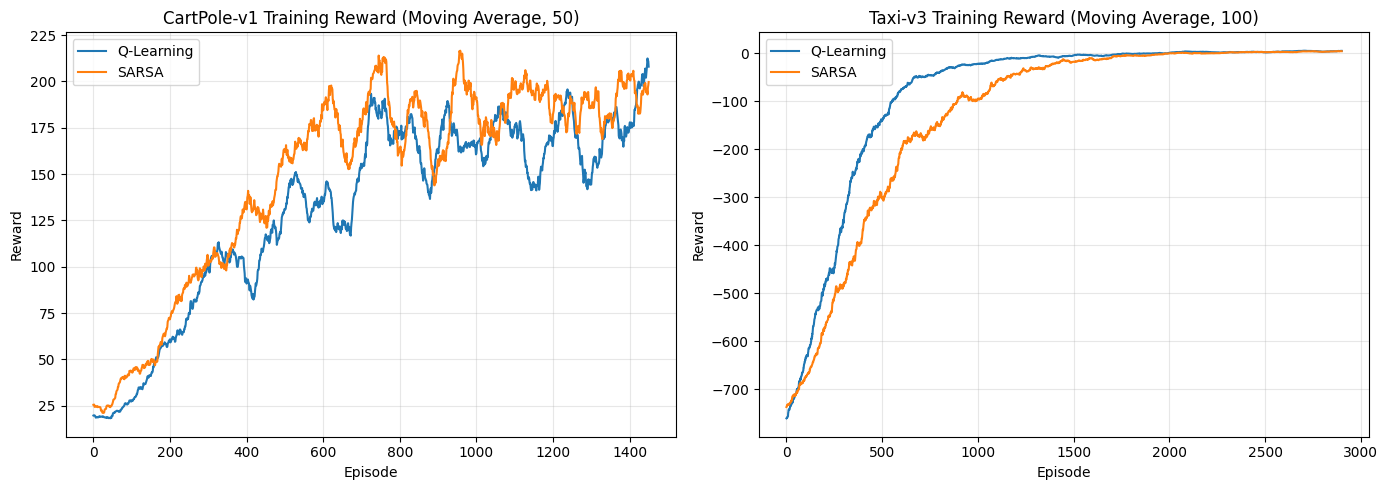

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(moving_average(cartpole_q_rewards, window=50), label="Q-Learning")
axes[0].plot(moving_average(cartpole_s_rewards, window=50), label="SARSA")
axes[0].set_title("CartPole-v1 Training Reward (Moving Average, 50)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(moving_average(taxi_q_rewards, window=100), label="Q-Learning")
axes[1].plot(moving_average(taxi_s_rewards, window=100), label="SARSA")
axes[1].set_title("Taxi-v3 Training Reward (Moving Average, 100)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Reward")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()